# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users

print("Cantidad de valores nulos users", users.isna().sum())

print("Proporción de valores nulos users")
users.isna().mean()


Cantidad de valores nulos users user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos users


user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64

In [11]:
# cantidad de nulos para usage
print("Cantidad de valores nulos usage: " )
print(usage.isna().sum())
print()
print("Proporción de valores nulos usage:" )
print( usage.isna().mean())

Cantidad de valores nulos usage: 
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos usage:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

  
date → 50 nulos → 0.12%
duration → 22,076 nulos → 55.19%
length → 17,896 nulos → 44.74%

- Indica qué harías: ¿imputar, eliminar, ignorar?
  
#**date (0.12%)**
✔ Está muy por debajo del 5%
📌 Interpretación: problema menor, probablemente errores puntuales de captura

✅ Decisión: Imputar o eliminar filas (impacto mínimo)


#**duration (55.19%)**
⚠ Está en un rango crítico (muy por encima del 30%)
📌 Más de la mitad de los datos faltan → alto riesgo de sesgo

👉 Acción recomendada:

NO imputar directamente sin análisis previo
Evaluar:
¿Está correlacionada con type o length?
¿Los nulos representan un caso válido (ej. eventos sin duración)?

Posibles caminos:

Si no aporta valor → eliminar columna
Si es clave → crear variable binaria (duration_missing)
Imputación solo si hay patrón claro (modelo predictivo)


#**length (44.74%)**
⚠ También alto porcentaje de nulos
📌 Similar problema que duration, aunque ligeramente menor

👉 Acción recomendada:

Analizar relación con duration:
Si ambas van juntas → podrían depender entre sí
Evaluar importancia para el negocio/modelo

Opciones:

Eliminar si no es crítica
Imputar con modelo si tiene valor predictivo
Crear flag de missing

#**Antes de decidir eliminar duration y length realizar:**

Análisis de correlación
Distribución de nulos por type
Ver si los nulos tienen significado (no siempre son “errores”)

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[["user_id","age"]].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`
  count: 4000 → no hay valores faltantes
  Parece un identificador secuencial o rango controlado
  No tiene valor analítico directo (solo sirve como ID)
- La columna `age`
  count: 4000 → aparentemente sin nulos
  Media razonable
  mediana con inconsistencia
  valor minimo fuera de rango
  maximo dentro del nivel logic

In [13]:
# explorar columnas numéricas de usage

usage[["id","user_id","duration","length"]].describe()




,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


Las Columnas id y user_id muestran distribuciones estables 
#**id** - se marca solo como identificador

#**user_id**  - nos puede servir para agregaciones por usuario mas no como variable predictiva

#**duration** - se observa con una distribución sesgada a ala derecha, con una alta dispersion

#**lenght** - se observa con una distribucion relativamente sesgada con la falta del 45% de los valores

se deberan tratar los outliers por medio de cap o winsorizacion
Evaluar la Imputación

asi como crear flags de missing

tanto **duration** como **length** tienen un alto indice de faltantes

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

users[columnas_user].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city`  presenta un 11.7 de  porcentaje de valores faltantes se recomienda imputar otratar como una sola categoria lo valores faltantes ya que de eliminarlos  tendriamos perdida de información crear la categoria desconocido seria una opción
- La columna `plan` se ve desbalanceada podria ocasionr un sesgo se recomienda mantener tal cual  cambiando la codificacion a booleana
   como recomendacion general  seria importante  revisar la relacion **City VS Plan** y **city VS duration/length**

In [15]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type`
- se ve sin valores faltantes
- no tiene cardinalidad
- **columna lista para usarse**


**age** → contiene -999, usado como valor sentinel (dato faltante mal codificado)
se recomienda 
Si son pocos → imputar (mediana)
Si son muchos → analizar patrón antes de imputar

Problema detectado en age
Requiere limpieza antes de cualquier análisis 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] =  pd.to_datetime(users['reg_date'])# completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])# completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
print(users.groupby(users['reg_date'].dt.year).size())


reg_date
2022    1314
2023    1316
2024    1330
2026      40
dtype: int64


Crecimiento estable: Los años 2022-2024 muestran un crecimiento muy consistente (~1,300 usuarios/año)
 Dato de 2026: Hay 40 registros con fecha de 2026, lo cual puede indicar:
Datos de prueba o simulación
Errores en la captura de fechas
Si estamos en 2026, son registros del año actual

❓ Falta 2025: No hay datos para 2025, lo que sugiere un salto en las fechas

In [19]:
# Revisar los años presentes en `date` de usage
print(usage.groupby(usage['date'].dt.year).size())


date
2024.0    39950
dtype: int64


Datos de uso/actividad para 2024: 39,950 registros
Contexto:
Esta tabla usage registra eventos o actividades de los usuarios, no los usuarios en sí:

Tabla users: 1,330 usuarios registrados en 2024
Tabla usage: 39,950 eventos/actividades en 2024
Promedio: ~30 eventos por usuario (39,950 ÷ 1,330)

Problemas Detectados:
1. Año 2026 en users['reg_date'] 

Cantidad: 40 usuarios (0.99% del total)
Problema: Fechas futuras imposibles (o gap de 2025)
Impacto: Bajo volumen pero puede distorsionar análisis temporales

2. Ausencia de año 2025 

Problema: Salto de 2024 → 2026 sin registros de 2025
Posible causa: Error sistemático en captura de datos

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city

users['city'] = users['city'].replace('?', pd.NA)
# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:

# Marcar como NA donde el año sea 2026
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
print(f"Fechas NA: {users['reg_date'].isna().sum()}")
users['reg_date'].describe()

Fechas NA: 40


count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration


usage.groupby('type').agg({'duration':[('total','count'), ('nulos', lambda x: x.isna().sum()),
        ('% nulos', lambda x: (x.isna().sum() / len(x)) * 100)]})



duration                    
        total    nulos    % nulos
type                             
call    17908      0.0   0.000000
text       16  22076.0  99.927576

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type').agg({'length':[('total','count'), ('nulos', lambda x: x.isna().sum()),
        ('% nulos', lambda x: (x.isna().sum() / len(x)) * 100)]})


length                    
      total    nulos    % nulos
type                           
call     12  17896.0  99.932991
text  22092      0.0   0.000000

DURATION:

call: 0% nulos → Las llamadas SIEMPRE tienen duración
text: 99.93% nulos → Los textos NUNCA tienen duración

LENGTH:

call: 99.93% nulos → Las llamadas NUNCA tienen longitud
text: 0% nulos → Los textos SIEMPRE tienen longitud


 - Los nulos NO son errores de captura
   - Son características estructurales del modelo de datos
   - Representan la incompatibilidad natural entre tipos de eventos

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Paso 1: Crear columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)


usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',      # cant_mensajes
    'is_call': 'sum',      # cant_llamadas
    'duration': 'sum'      # minutos (en segundos)
}).reset_index()

usage_agg['duration'] = usage_agg['duration'] / 60

# Verificar resultado
usage_agg.head(5)


,user_id,is_text,is_call,duration
0,10000,7,3,0.395000
1,10001,5,10,0.553000
2,10002,5,2,0.179000
3,10003,11,3,0.149833
4,10004,4,3,0.133500


In [26]:
# Renombrar columnas
# Paso 3: Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,0.395
1,10001,5,10,0.553
2,10002,5,2,0.179


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')


user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,0.395000
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,0.553000
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,0.179000
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,0.149833
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,0.133500


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
users_2024 = user_profile[user_profile['reg_date'].dt.year == 2024]

# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Resumen estadístico completo

print("RESUMEN ESTADÍSTICO - USUARIOS 2024")

resumen = users_2024[columnas_numericas].describe()
print(resumen)

# Agregar mediana (no viene en .describe())
print()
print("MEDIANAS")

print(users_2024[columnas_numericas].median())


RESUMEN ESTADÍSTICO - USUARIOS 2024
               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  1330.000000    1330.000000    1330.000000           1330.000000
mean     48.414286       5.500000       4.557143              0.402111
std      17.963443       2.382293       2.140329              0.324310
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000              0.188875
50%      48.000000       5.000000       4.000000              0.338750
75%      64.000000       7.000000       6.000000              0.542375
max      79.000000      16.000000      13.000000              2.594833

MEDIANAS
age                     48.00000
cant_mensajes            5.00000
cant_llamadas            4.00000
cant_minutos_llamada     0.33875
dtype: float64


In [29]:
users_2024['plan'].value_counts(normalize=True) * 100



Basico     65.639098
Premium    34.360902
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

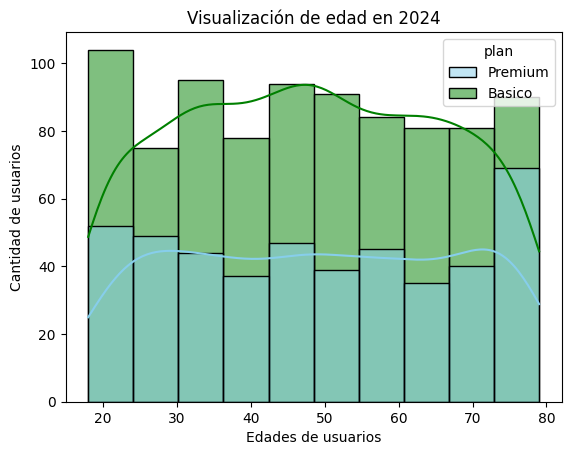

In [30]:

# Histograma para visualizar la edad (age)
sns.histplot(data=users_2024,x='age', hue='plan',bins=10,  palette=['skyblue','green'], kde=True)
plt.xlabel('Edades de usuarios')
plt.ylabel('Cantidad de usuarios')
plt.title('Visualización de edad en 2024')
plt.show()


💡Insights: 
1. Distribución general

Ambas poblaciones (Premium vs Básico) cubren prácticamente todo el rango de edad (≈18 a 80 años), lo que indica una base de usuarios diversa.
No hay sesgos extremos hacia edades muy jóvenes o muy mayores; la distribución es relativamente uniforme.

2. Diferencias entre planes

El plan Básico domina en volumen en casi todos los rangos de edad. Esto sugiere que es la puerta de entrada principal.
El plan Premium tiene menor cantidad, pero mantiene presencia constante en todos los rangos, lo que indica adopción transversal.

3. Concentraciones relevantes

Se observa una ligera concentración en edades 30–55 años para ambos planes, especialmente en Básico.
En Premium, la curva es más “plana”, lo que sugiere que no depende tanto de un segmento etario específico.. 6. Hipótesis accionables

Testear campañas de upgrade a Premium enfocadas en usuarios de 35–50 años.
Analizar si el uso/engagement (no solo edad) explica mejor la conversión.
Investigar si el precio es la principal barrera en menores de 30.

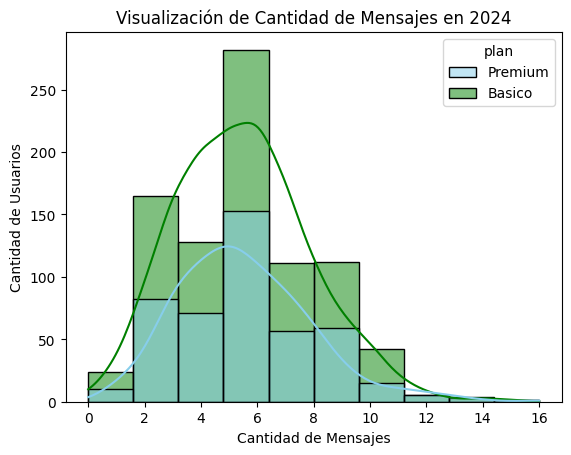

In [31]:
# Histograma para visualizar la cant_mensajes


sns.histplot(data=users_2024,x='cant_mensajes', hue='plan',bins=10,  palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.title('Visualización de Cantidad de Mensajes en 2024')
plt.show()



💡Insights: 
1. Distribución de uso (mensajes)
La mayor concentración está entre 4 y 7 mensajes, con un pico claro alrededor de 5–6.
La distribución tiene cola hacia la derecha (usuarios que envían muchos mensajes), pero son minoría.
2. Diferencias entre planes
El plan Básico concentra más usuarios en todos los rangos → consistente con el histograma anterior (mayor base).
El plan Premium muestra una ligera tendencia a mayores volúmenes de mensajes, especialmente en rangos medios-altos (6–10).

 los usuarios Premium tienden a usar más el producto, aunque no de forma radicalmente distinta.

 Insights accionables
Upselling basado en uso:
Usuarios que pasan de 5+ mensajes son candidatos naturales a Premium.
Activación temprana:
Usuarios en 0–3 mensajes necesitan triggers (notificaciones, onboarding, incentivos).
Retención de alto valor:
El segmento 8+ mensajes es pequeño pero valioso → foco en retención

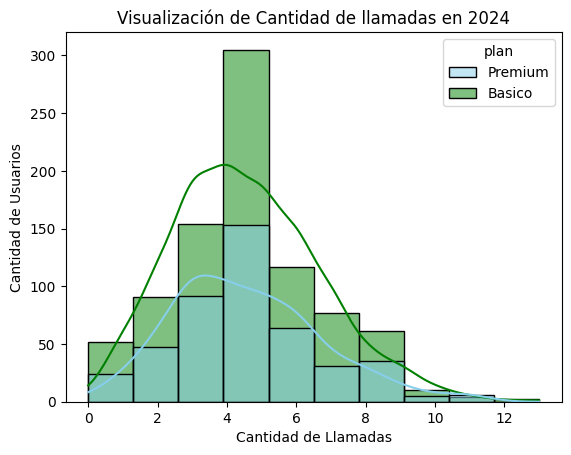

In [32]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=users_2024,x='cant_llamadas', hue='plan',bins=10,  palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.title('Visualización de Cantidad de llamadas en 2024')
plt.show()



💡Insights: 
1. Distribución general de llamadas
Pico claro en 3 a 5 llamadas → comportamiento más concentrado que en mensajes.
Distribución con cola derecha moderada (usuarios que hacen muchas llamadas, pero pocos).
Comparado con mensajes, el uso de llamadas es más compacto y menos disperso.
2. Diferencias entre planes
El plan Básico sigue dominando en volumen total.
El plan Premium tiene una mayor proporción relativa en rangos más altos (5–9 llamadas).


El uso intensivo de llamadas está más asociado a usuarios Premium que el uso de mensajes.

Hipótesis accionables
Existe un umbral de valor en llamadas (~4 llamadas) donde el usuario percibe mayor necesidad del servicio.
Usuarios que usan más llamadas tienen:
Mayor engagement
Mayor probabilidad de pagar
Las llamadas pueden estar asociadas a casos de uso más críticos (trabajo, coordinación, etc.).

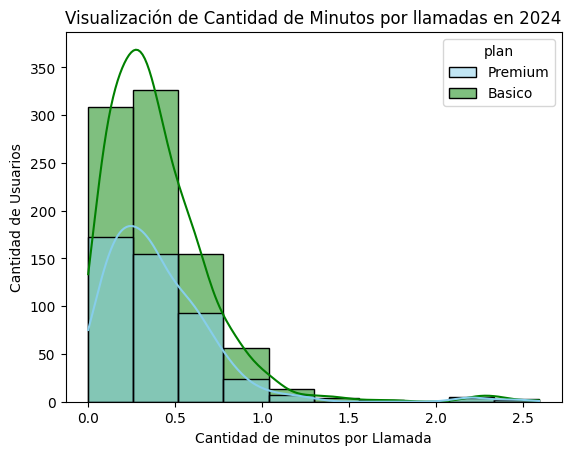

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=users_2024,x='cant_minutos_llamada', hue='plan',bins=10,  palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de minutos por Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.title('Visualización de Cantidad de Minutos por llamadas en 2024')
plt.show()



💡Insights: 
1. Distribución general (minutos por llamada)
Fuerte concentración en rangos bajos (≈0.1 a 0.6 minutos).
Distribución altamente sesgada a la derecha → muchas llamadas cortas, pocas muy largas.
Existen outliers claros (2+ minutos), pero son casos excepcionales.


El producto se usa principalmente para interacciones rápidas, no para llamadas largas.

2. Diferencias entre planes
El plan Básico domina en volumen total, especialmente en llamadas muy cortas.
El plan Premium tiene una distribución ligeramente más extendida, con mayor presencia relativa en llamadas más largas.

👉 Insight clave:
Premium no solo llama más (como vimos antes), sino que también tiende a tener llamadas más largas.


Existe un punto de quiebre (~0.5–0.7 min) donde el usuario obtiene más valor.
Usuarios que combinan:
muchas llamadas +
mayor duración
⇒ son los power users reales.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

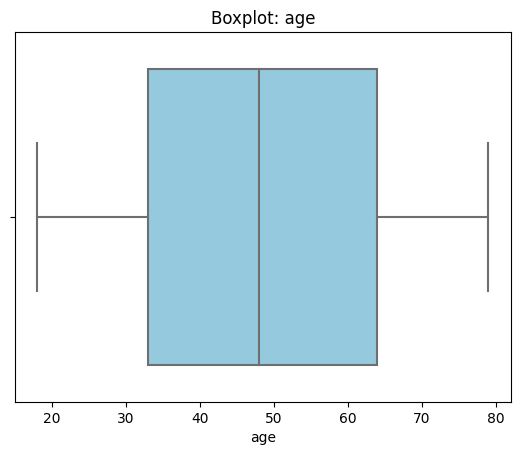

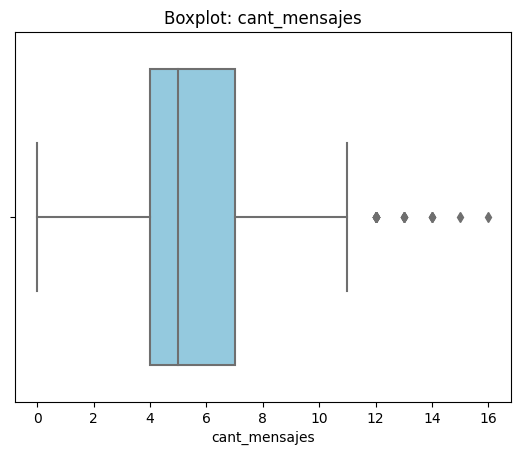

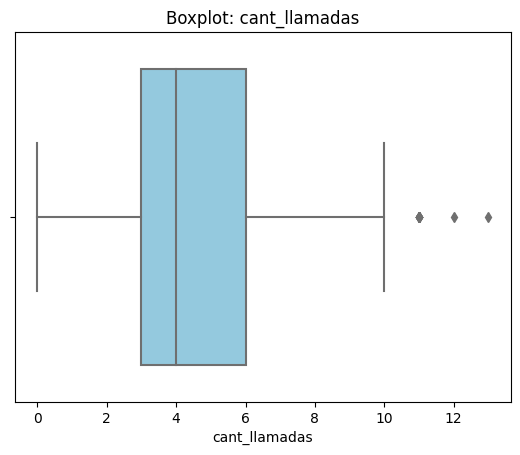

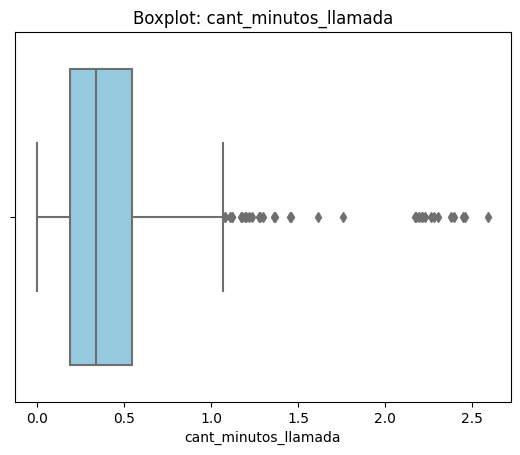

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=users_2024[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
   
    plt.show()


💡Insights: 
- Age:
- No se observan outliers relevantes.

👉 Insight:
La distribución es limpia, sin datos atípicos ni problemas de calidad en esta variable.

- cant_mensajes:
- 📊 1. Distribución general
Mediana ~5 mensajes → el usuario típico envía pocos mensajes.
Q1 ~4 / Q3 ~7 → el 50% de los usuarios está en un rango bastante estrecho (4–7).
Esto indica baja variabilidad en el comportamiento normal.

👉 Insight: la mayoría de usuarios tiene un nivel de actividad bastante homogéneo.

📉 2. Sesgo (skewness)
La cola derecha es más larga (llega hasta ~11 sin outliers).
Hay varios valores extremos entre 12 y 16.

👉 Insight:
La distribución está sesgada a la derecha, lo que sugiere que:

Hay un pequeño grupo de usuarios mucho más activos que el promedio.
🚨 3. Outliers (muy importante)
Se observan múltiples outliers altos (≈12–16 mensajes).
No hay outliers bajos relevantes.

👉 Insight clave:

Existe un segmento claro de “power users”.
Este grupo puede estar influyendo significativamente en métricas agregadas (como promedio).

- cant_llamadas: ...
 📊 1. Distribución general
Mediana ~4 llamadas
Q1 ~3 / Q3 ~6
Rango típico: 3–6 llamadas

👉 Insight:
El comportamiento central es muy parecido al de mensajes, pero ligeramente más concentrado.

📉 2. Variabilidad
Caja relativamente compacta → baja dispersión en usuarios promedio
Bigotes van de ~0 a ~10 → existe cierta amplitud, pero controlada

👉 Insight:
La mayoría de usuarios tiene un uso bastante predecible y estable en llamadas.

📈 3. Sesgo
Cola derecha más larga
Outliers en ~11–13

👉 Insight:
También hay asimetría positiva, pero:

menos extrema que en mensajes
🚨 4. Outliers
Pocos outliers (≈3 puntos)
Menor intensidad que en mensajes (donde había más y más extremos)

👉 Insight clave:

Existen heavy callers, pero son:
menos frecuentes
menos extremos



- cant_minutos_llamada: ...

  1. Distribución central
Mediana ~0.3–0.4 minutos
Q1 ~0.2 / Q3 ~0.5
La mayoría de llamadas son muy cortas

👉 Insight:

El uso típico de llamadas no es para conversaciones largas, sino interacciones rápidas.

📉 2. Asimetría extrema (clave)
Cola derecha muy larga
Valores llegan hasta ~2.6 minutos
Muchísimos outliers

👉 Insight fuerte:

Esta variable está altamente sesgada a la derecha (heavy tail)
→ típico de comportamientos tipo “pocos usuarios consumen mucho”

🚨 3. Outliers
Hay dos niveles de outliers:
Moderados (~1.0–1.6)
Extremos (~2.1–2.6)

👉 Insight crítico:

No es solo variabilidad → hay segmentos distintos de comportamiento
Posibles:
usuarios con conversaciones reales
usuarios con uso intensivo / profesional
incluso anomalías (fraude, bots, uso indebido)

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_limites:
    Q1 = users_2024[col].quantile(0.25)
    Q3 = users_2024[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    outliers = users_2024[users_2024[col] > upper]
    print(col," Q1= ",Q1)
    print()
    print(col," Q3= ",Q3)
    print()
    print(col," IQR= ",IQR)
    print()
    print(col," Upper= ",upper)
    print()
    print(col," Outliers= ")
    print(outliers)



age  Q1=  33.0

age  Q3=  64.0

age  IQR=  31.0

age  Upper=  110.5

age  Outliers= 
Empty DataFrame
Columns: [user_id, first_name, last_name, age, city, reg_date, plan, churn_date, cant_mensajes, cant_llamadas, cant_minutos_llamada]
Index: []
cant_mensajes  Q1=  4.0

cant_mensajes  Q3=  7.0

cant_mensajes  IQR=  3.0

cant_mensajes  Upper=  11.5

cant_mensajes  Outliers= 
      user_id first_name last_name   age      city  \
2666    12666      Mateo    Garcia  20.0      Cali   
2676    12676       Luis    Garcia  36.0       MTY   
2699    12699       Luis     Lopez  74.0       GDL   
2794    12794     Carlos     Lopez  30.0      CDMX   
2952    12952      Sofia     Gomez  65.0    Bogotá   
3094    13094       Luis    Garcia  29.0      CDMX   
3100    13100        Ana     Lopez  35.0       NaN   
3255    13255     Carlos    Garcia  77.0    Bogotá   
3301    13301      Mateo     Gomez  29.0    Bogotá   
3345    13345       Luis   Ramirez  50.0       NaN   
3406    13406      Mateo    Gar

In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,0.388618
std,17.690408,2.358416,2.144238,0.302802
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,0.185333
50%,47.000000,5.000000,4.000000,0.329667
75%,63.000000,7.000000,6.000000,0.523583
max,79.000000,17.000000,15.000000,2.594833


💡Insights: 

Variable	           Decisión         	   Justificación
cant_mensajes       	✅ Mantener	   Engagement real, sin distorsión
cant_llamadas	        ✅ Mantener	       Outliers moderados
cant_minutos_llamada	⚠️ Segmentar	   Heavy tail fuerte

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [44]:
# Crear columna grupo_uso

user_profile.loc[:, 'grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)






In [45]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,0.395000,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,0.553000,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,0.179000,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,0.149833,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,0.133500,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [46]:
# Crear columna grupo_edad
user_profile.loc[:, 'grupo_edad'] = np.where(
    (user_profile['age'] < 30),'Joven',
    np.where(
        (user_profile['age'] < 60),'Adulto',
        'Adulto Mayor'
    )
)

In [47]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,0.395000,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,0.553000,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,0.179000,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,0.149833,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,0.133500,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

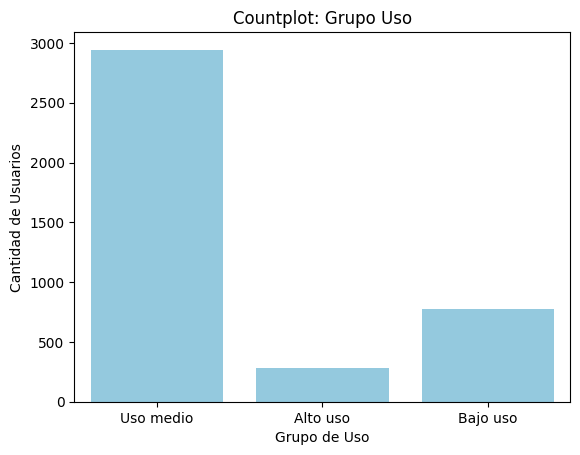

In [51]:
# Visualización de los segmentos por uso


sns.countplot(x=user_profile['grupo_uso'], color='skyblue')
plt.title(f'Countplot: Grupo Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()



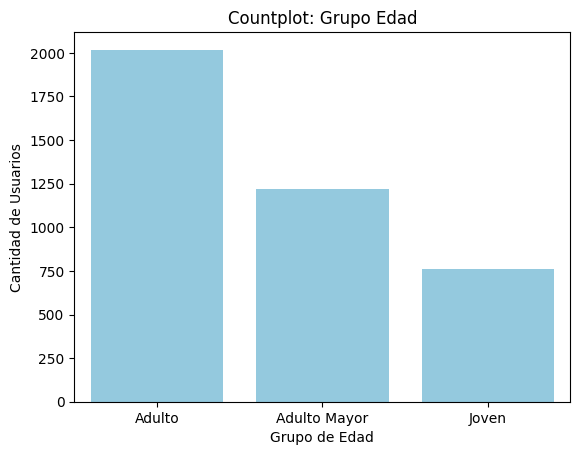

In [52]:
# Visualización de los segmentos por edad
sns.countplot(x=user_profile['grupo_edad'], color='skyblue')
plt.title(f'Countplot: Grupo Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()




---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

El análisis exploratorio indica que los datos presentan alta calidad general, sin problemas críticos de integridad:

No se identificaron valores nulos relevantes en variables clave.
La variable edad no presenta outliers ni inconsistencias.
Las variables de uso (mensajes, llamadas) muestran distribuciones estables en la mayoría de los usuarios.

Sin embargo, sí se detectaron problemas analíticos importantes:

Asimetría (skewness) positiva en variables de uso.
Presencia de outliers, especialmente en:
Mensajes (~12–16)
Llamadas (~11–13)
Minutos de llamada (hasta ~2.6, altamente sesgado)

👉 Magnitud del problema:

Los outliers representan un porcentaje pequeño (estimado <5–10%), pero tienen alto impacto en promedios y métricas agregadas.
En minutos de llamada, el fenómeno es más severo (heavy tail), indicando que pocos usuarios concentran gran parte del consumo.


🔍 **Segmentos por Edad**

Jóvenes (<30): mayor probabilidad de uso intensivo (mensajes principalmente)
Adultos (30–60): comportamiento más estable y predecible
Adultos mayores (>60): menor nivel de uso general


📊 **Segmentos por Nivel de Uso**

Bajo uso: <5 llamadas y <5 mensajes
Uso medio: consumo moderado y consistente
Alto uso (power users): superan ambos umbrales


➡️ Esto sugiere que ...


💡 **Recomendaciones**

El negocio presenta una base de usuarios estable y predecible, con un pequeño pero importante segmento de usuarios intensivos que concentra el consumo.

La oportunidad clave para ConnectaTel está en:

Segmentar correctamente
Diseñar planes diferenciados
Optimizar monetización sin afectar la experiencia

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`